Loading Ridge model and test data ...
  y_true: (78, 96)  |  y_pred: (78, 96)
Saved → data/processed/plots/day_test_0.png


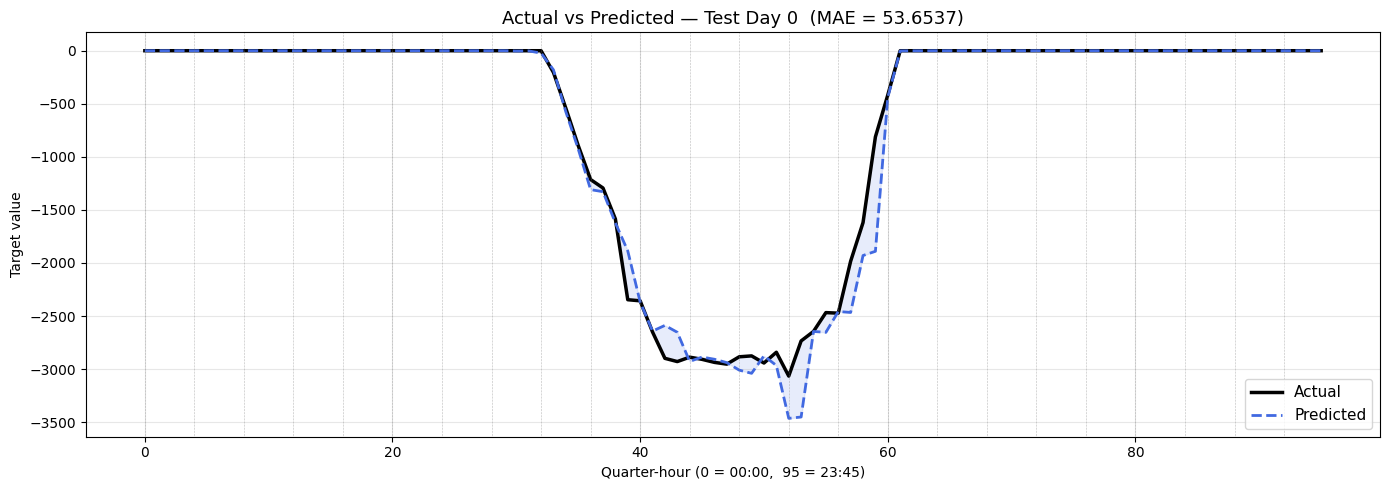

Saved → data/processed/plots/day_test_10.png


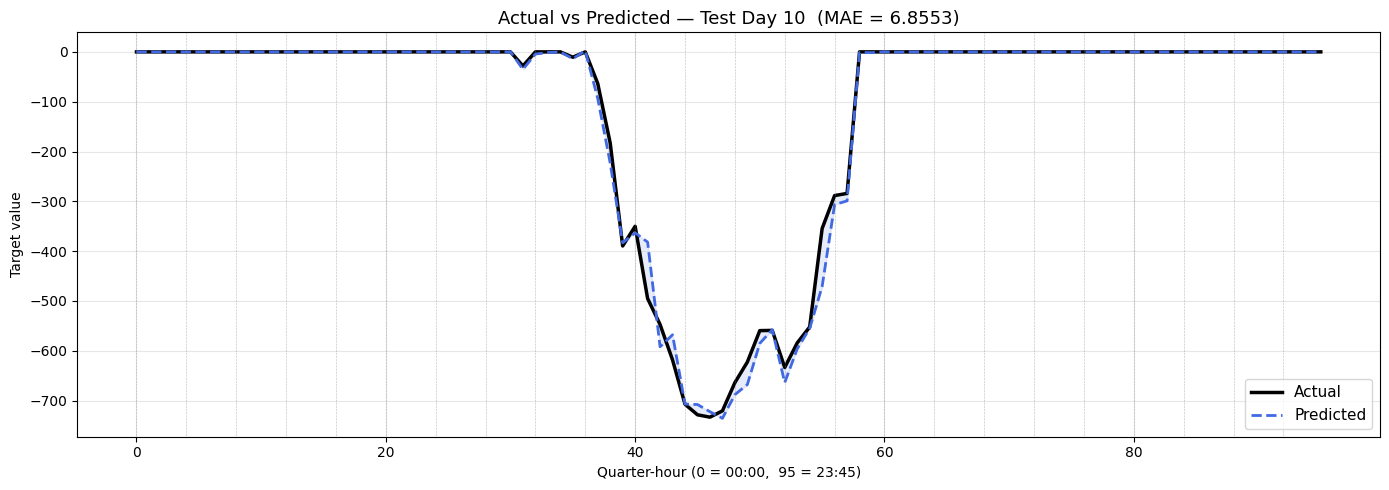

Saved → data/processed/plots/grid_test_6days.png


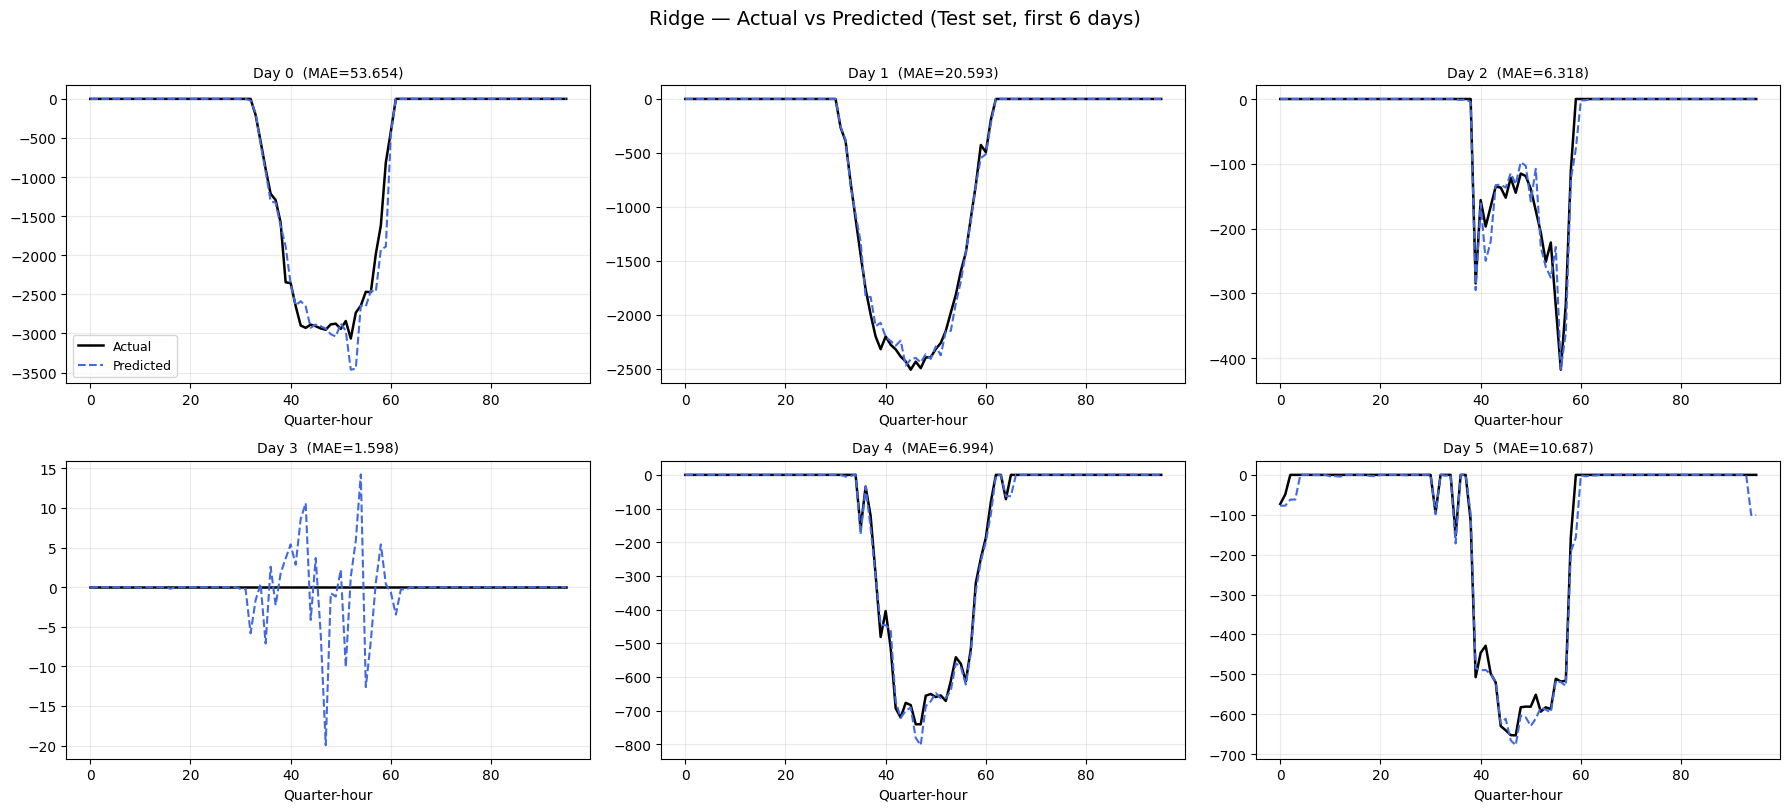

Saved → data/processed/plots/full_series_test_30days.png


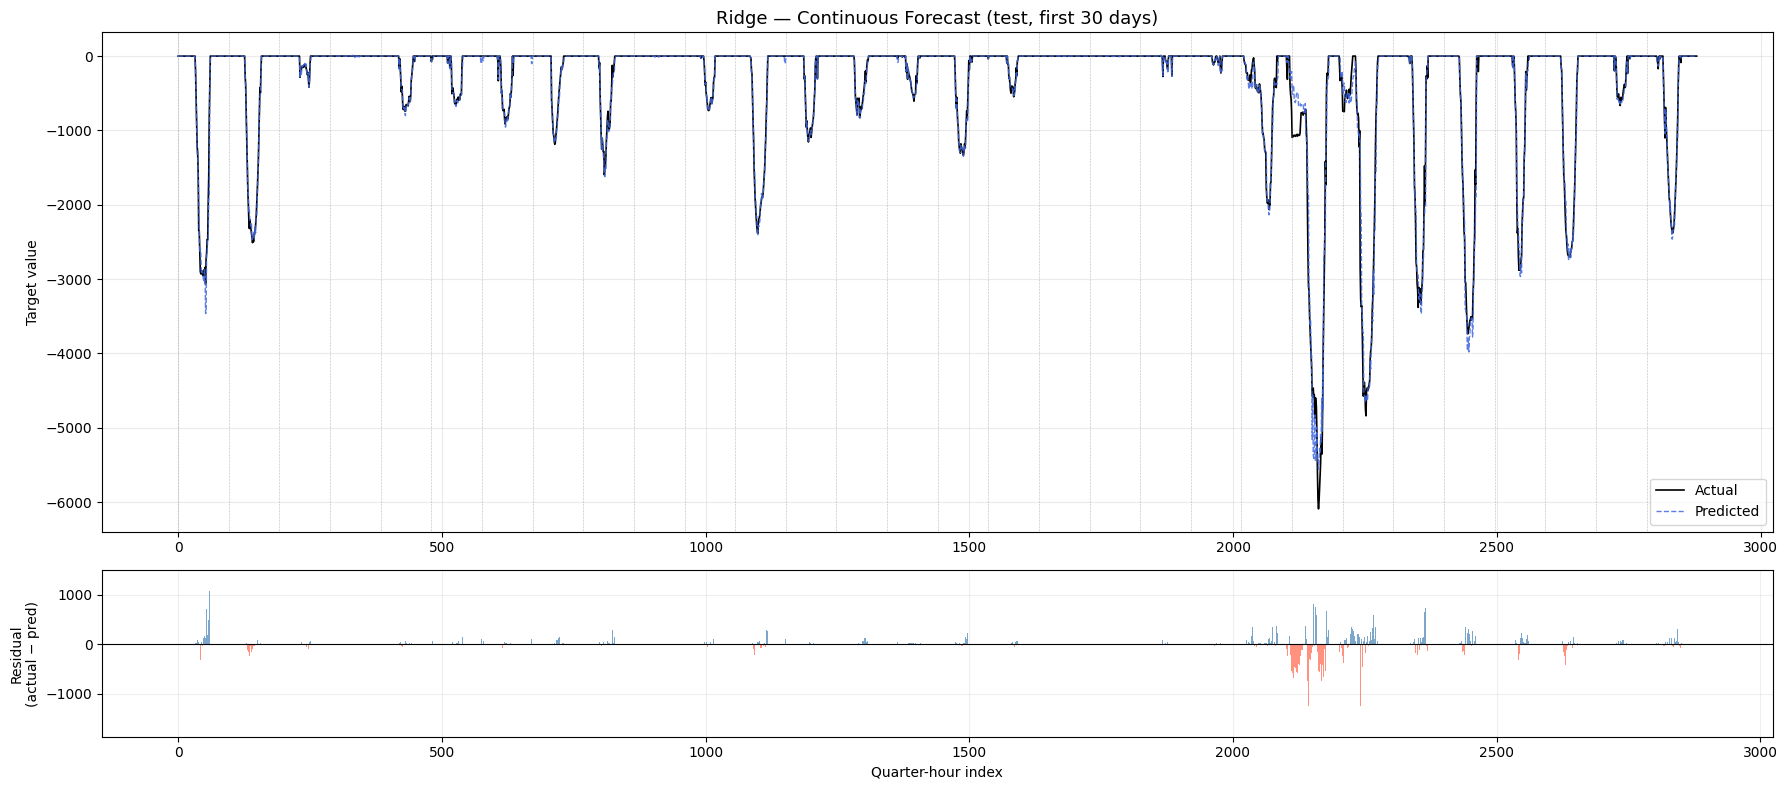

Saved → data/processed/plots/scatter_test.png


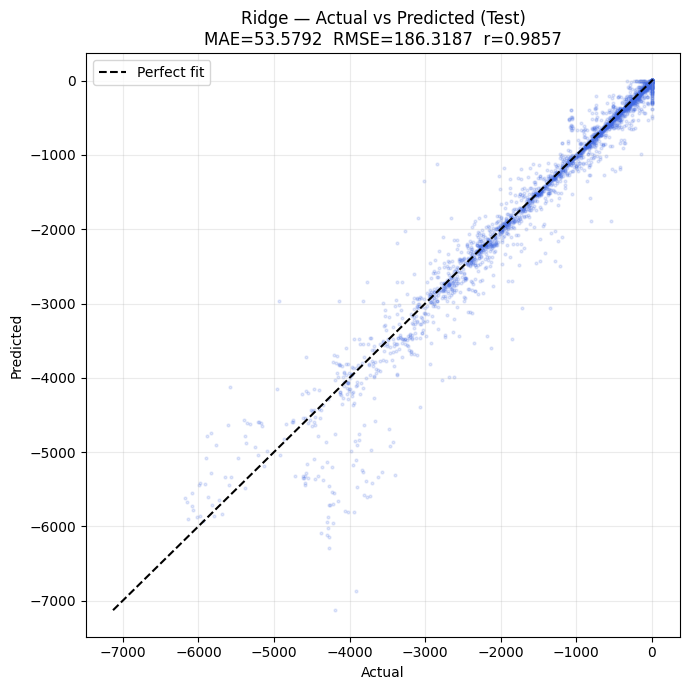

In [1]:
"""
visualize.py
------------
Plot actual vs predicted for Ridge (or any model).
Works on train, val, or test split.

Run:
    python src/visualize.py
"""

import os
import numpy as np
import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── CONFIG ────────────────────────────────────────────────────────────────────
PROCESSED_DIR = "data/processed"
MODELS_DIR    = "models"
PLOTS_DIR     = "data/processed/plots"
SEQ_LEN       = 96


# ── LOAD & PREDICT ────────────────────────────────────────────────────────────
def load_and_predict(split="test"):
    model    = joblib.load(os.path.join(MODELS_DIR, "xgboost.pkl"))
    scaler_y = joblib.load(os.path.join(MODELS_DIR, "scaler_y.pkl"))

    X = np.load(os.path.join(PROCESSED_DIR, f"X_{split}.npy"))   # (n, 96, 7)

    # Load raw (unscaled) target
    if split == "test":
        y_true = np.load(os.path.join(PROCESSED_DIR, "test_y_raw.npy"))
    else:
        y_sc   = np.load(os.path.join(PROCESSED_DIR, f"y_{split}.npy"))
        y_true = scaler_y.inverse_transform(y_sc)

    # Predict
    X_flat  = X.reshape(len(X), -1)                              # (n, 672)
    y_pred  = scaler_y.inverse_transform(model.predict(X_flat))  # (n, 96)

    return y_true, y_pred


# ── PLOT 1: Single Day ────────────────────────────────────────────────────────
def plot_single_day(y_true, y_pred, day_idx=0, split="test", save=True):
    """
    Overlay actual vs predicted for one specific day.
    """
    os.makedirs(PLOTS_DIR, exist_ok=True)
    quarters = range(SEQ_LEN)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(quarters, y_true[day_idx],  label="Actual",    color="black",
            linewidth=2.5)
    ax.plot(quarters, y_pred[day_idx],  label="Predicted", color="royalblue",
            linewidth=2, linestyle="--")
    ax.fill_between(quarters, y_true[day_idx], y_pred[day_idx],
                    alpha=0.12, color="royalblue")

    mae_day = np.mean(np.abs(y_true[day_idx] - y_pred[day_idx]))
    ax.set_title(f"Actual vs Predicted — {split.capitalize()} Day {day_idx}  "
                 f"(MAE = {mae_day:.4f})", fontsize=13)
    ax.set_xlabel("Quarter-hour (0 = 00:00,  95 = 23:45)")
    ax.set_ylabel("Target value")
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)

    # Mark quarter-hour boundaries for each hour
    for h in range(0, SEQ_LEN, 4):
        ax.axvline(h, color="gray", linewidth=0.4, linestyle=":")

    plt.tight_layout()
    if save:
        path = os.path.join(PLOTS_DIR, f"day_{split}_{day_idx}.png")
        plt.savefig(path, dpi=150)
        print(f"Saved → {path}")
    plt.show()


# ── PLOT 2: Multi-Day Grid ────────────────────────────────────────────────────
def plot_day_grid(y_true, y_pred, n_days=6, split="test", save=True):
    """
    Grid of n_days subplots — gives a quick overview of forecast quality
    across different days (weekdays, weekends, price spike days, etc.)
    """
    os.makedirs(PLOTS_DIR, exist_ok=True)
    n_cols = 3
    n_rows = n_days // n_cols + int(n_days % n_cols > 0)
    quarters = range(SEQ_LEN)

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(18, 4 * n_rows), sharey=False)
    axes = axes.flatten()

    for i in range(n_days):
        ax = axes[i]
        ax.plot(quarters, y_true[i], color="black",     linewidth=1.8, label="Actual")
        ax.plot(quarters, y_pred[i], color="royalblue", linewidth=1.5,
                linestyle="--", label="Predicted")
        mae_d = np.mean(np.abs(y_true[i] - y_pred[i]))
        ax.set_title(f"Day {i}  (MAE={mae_d:.3f})", fontsize=10)
        ax.set_xlabel("Quarter-hour")
        ax.grid(alpha=0.25)
        if i == 0:
            ax.legend(fontsize=9)

    # Hide unused subplots
    for j in range(n_days, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Ridge — Actual vs Predicted ({split.capitalize()} set, "
                 f"first {n_days} days)", fontsize=14, y=1.01)
    plt.tight_layout()
    if save:
        path = os.path.join(PLOTS_DIR, f"grid_{split}_{n_days}days.png")
        plt.savefig(path, dpi=150, bbox_inches="tight")
        print(f"Saved → {path}")
    plt.show()


# ── PLOT 3: Flattened Full Series ─────────────────────────────────────────────
def plot_full_series(y_true, y_pred, split="test", max_days=30, save=True):
    """
    Flatten all days into a single continuous time axis.
    Shows overall tracking quality over time.
    """
    os.makedirs(PLOTS_DIR, exist_ok=True)
    n = min(max_days, len(y_true))

    actual = y_true[:n].flatten()    # (n*96,)
    pred   = y_pred[:n].flatten()    # (n*96,)
    t      = range(len(actual))

    fig, axes = plt.subplots(2, 1, figsize=(18, 8),
                             gridspec_kw={"height_ratios": [3, 1]})

    # Top panel — overlay
    axes[0].plot(t, actual, label="Actual",    color="black",     linewidth=1.2)
    axes[0].plot(t, pred,   label="Predicted", color="royalblue", linewidth=1.0,
                 linestyle="--", alpha=0.85)
    axes[0].set_title(f"Ridge — Continuous Forecast ({split}, first {n} days)",
                      fontsize=13)
    axes[0].set_ylabel("Target value")
    axes[0].legend(fontsize=10)
    axes[0].grid(alpha=0.25)

    # Mark day boundaries
    for d in range(0, n * SEQ_LEN, SEQ_LEN):
        axes[0].axvline(d, color="gray", linewidth=0.4, linestyle=":")

    # Bottom panel — residuals
    residuals = actual - pred
    axes[1].bar(t, residuals, color=np.where(residuals >= 0, "steelblue", "tomato"),
                width=1.0, alpha=0.7)
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_ylabel("Residual\n(actual − pred)")
    axes[1].set_xlabel("Quarter-hour index")
    axes[1].grid(alpha=0.2)

    plt.tight_layout()
    if save:
        path = os.path.join(PLOTS_DIR, f"full_series_{split}_{n}days.png")
        plt.savefig(path, dpi=150)
        print(f"Saved → {path}")
    plt.show()


# ── PLOT 4: Scatter — Actual vs Predicted ────────────────────────────────────
def plot_scatter(y_true, y_pred, split="test", save=True):
    """
    Scatter plot of all actual vs predicted values.
    Perfect model = all points on the diagonal.
    """
    os.makedirs(PLOTS_DIR, exist_ok=True)
    actual = y_true.flatten()
    pred   = y_pred.flatten()

    mae   = np.mean(np.abs(actual - pred))
    rmse  = np.sqrt(np.mean((actual - pred) ** 2))
    corr  = np.corrcoef(actual, pred)[0, 1]

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(actual, pred, alpha=0.15, s=4, color="royalblue", rasterized=True)

    # Perfect prediction line
    lims = [min(actual.min(), pred.min()), max(actual.max(), pred.max())]
    ax.plot(lims, lims, "k--", linewidth=1.5, label="Perfect fit")

    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title(f"Ridge — Actual vs Predicted ({split.capitalize()})\n"
                 f"MAE={mae:.4f}  RMSE={rmse:.4f}  r={corr:.4f}", fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.25)

    plt.tight_layout()
    if save:
        path = os.path.join(PLOTS_DIR, f"scatter_{split}.png")
        plt.savefig(path, dpi=150)
        print(f"Saved → {path}")
    plt.show()


# ── MAIN ──────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    # Change split to "train" or "val" to inspect those sets
    SPLIT = "test"

    print(f"Loading Ridge model and {SPLIT} data ...")
    y_true, y_pred = load_and_predict(split=SPLIT)
    print(f"  y_true: {y_true.shape}  |  y_pred: {y_pred.shape}")

    # ── Run all 4 plots ──
    plot_single_day(y_true, y_pred, day_idx=0,  split=SPLIT)   # first day
    plot_single_day(y_true, y_pred, day_idx=10, split=SPLIT)   # pick any day
    plot_day_grid(y_true, y_pred,   n_days=6,   split=SPLIT)   # 6-day overview
    plot_full_series(y_true, y_pred, max_days=30, split=SPLIT) # 30-day continuous
    plot_scatter(y_true, y_pred,                 split=SPLIT)  # scatter